In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import os
import re
from datetime import datetime
import openpyxl as op
import seaborn as sns

In [2]:
df = pd.read_excel("CleanedCollinandOwenDummy.xlsx", sheet_name=4)

In [3]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,159.40,181.40,145.64,143.08,165.48,120.40,105.72,91.16,125.24,126.80
1,NaN,159.28,181.12,146.88,147.24,166.40,121.28,105.48,81.64,125.60,126.64
2,NaN,159.08,180.68,148.68,151.92,167.68,121.72,105.80,74.76,125.60,126.72
3,NaN,158.84,180.32,150.12,155.80,169.04,121.96,106.40,69.48,125.56,126.84
4,NaN,158.60,180.40,151.84,157.80,169.88,122.16,106.56,65.44,125.60,127.00


In [4]:
df = df.iloc[:, 1:]

In [5]:
df

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,159.40,181.40,145.64,143.08,165.48,120.40,105.72,91.16,125.24,126.80
1,159.28,181.12,146.88,147.24,166.40,121.28,105.48,81.64,125.60,126.64
2,159.08,180.68,148.68,151.92,167.68,121.72,105.80,74.76,125.60,126.72
3,158.84,180.32,150.12,155.80,169.04,121.96,106.40,69.48,125.56,126.84
4,158.60,180.40,151.84,157.80,169.88,122.16,106.56,65.44,125.60,127.00
...,...,...,...,...,...,...,...,...,...,...
165,126.20,133.44,140.08,134.92,140.28,106.56,121.20,124.48,117.40,123.84
166,127.00,123.56,140.24,139.60,134.56,106.88,121.00,124.44,117.44,123.96
167,127.92,117.04,140.64,142.24,128.04,107.20,120.88,124.36,117.60,124.40
168,127.96,112.08,140.40,142.84,120.32,107.12,120.60,123.44,117.72,124.80


In [6]:
df = df.T

In [7]:
df

,0,1,2,3,4,5,6,7,8,9,...,160,161,162,163,164,165,166,167,168,169
Unnamed: 1,159.40,159.28,159.08,158.84,158.60,157.96,157.92,157.48,157.32,157.00,...,127.76,126.60,125.52,125.36,125.60,126.20,127.00,127.92,127.96,126.60
Unnamed: 2,181.40,181.12,180.68,180.32,180.40,180.60,180.80,181.32,181.64,181.76,...,172.72,167.60,158.68,150.40,141.88,133.44,123.56,117.04,112.08,110.00
Unnamed: 3,145.64,146.88,148.68,150.12,151.84,153.08,154.24,154.76,155.44,155.84,...,138.96,139.60,139.44,139.64,139.52,140.08,140.24,140.64,140.40,140.00
Unnamed: 4,143.08,147.24,151.92,155.80,157.80,158.40,159.28,160.48,161.64,162.72,...,102.40,108.64,115.08,122.24,129.08,134.92,139.60,142.24,142.84,142.40
Unnamed: 5,165.48,166.40,167.68,169.04,169.88,170.20,170.76,171.28,171.92,172.12,...,142.72,143.04,142.96,142.88,141.96,140.28,134.56,128.04,120.32,111.76
Unnamed: 6,120.40,121.28,121.72,121.96,122.16,122.48,122.12,122.16,122.60,123.08,...,106.92,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24
Unnamed: 7,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24,107.44,...,120.88,120.84,120.96,121.28,121.16,121.20,121.00,120.88,120.60,120.60
Unnamed: 8,91.16,81.64,74.76,69.48,65.44,63.44,63.44,67.56,73.80,81.48,...,126.04,126.00,125.76,125.28,125.04,124.48,124.44,124.36,123.44,121.64
Unnamed: 9,125.24,125.60,125.60,125.56,125.60,125.72,125.64,125.60,125.80,125.84,...,117.64,117.72,117.48,117.36,117.36,117.40,117.44,117.60,117.72,117.60
Unnamed: 10,126.80,126.64,126.72,126.84,127.00,126.84,127.00,127.00,127.16,127.20,...,123.16,123.40,123.36,123.48,123.52,123.84,123.96,124.40,124.80,125.04


First 5 columns is Collin, next 5 is Owen

In [8]:
# build the label list
labels = ['Collin']*5 + ['Owen_Dummy']*5

# assign it as a new column
df['label'] = labels

In [122]:
df

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
Unnamed: 1,159.40,159.28,159.08,158.84,158.60,157.96,157.92,157.48,157.32,157.00,...,126.60,125.52,125.36,125.60,126.20,127.00,127.92,127.96,126.60,Collin
Unnamed: 2,181.40,181.12,180.68,180.32,180.40,180.60,180.80,181.32,181.64,181.76,...,167.60,158.68,150.40,141.88,133.44,123.56,117.04,112.08,110.00,Collin
Unnamed: 3,145.64,146.88,148.68,150.12,151.84,153.08,154.24,154.76,155.44,155.84,...,139.60,139.44,139.64,139.52,140.08,140.24,140.64,140.40,140.00,Collin
Unnamed: 4,143.08,147.24,151.92,155.80,157.80,158.40,159.28,160.48,161.64,162.72,...,108.64,115.08,122.24,129.08,134.92,139.60,142.24,142.84,142.40,Collin
Unnamed: 5,165.48,166.40,167.68,169.04,169.88,170.20,170.76,171.28,171.92,172.12,...,143.04,142.96,142.88,141.96,140.28,134.56,128.04,120.32,111.76,Collin
Unnamed: 6,120.40,121.28,121.72,121.96,122.16,122.48,122.12,122.16,122.60,123.08,...,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24,Owen_Dummy
Unnamed: 7,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24,107.44,...,120.84,120.96,121.28,121.16,121.20,121.00,120.88,120.60,120.60,Owen_Dummy
Unnamed: 8,91.16,81.64,74.76,69.48,65.44,63.44,63.44,67.56,73.80,81.48,...,126.00,125.76,125.28,125.04,124.48,124.44,124.36,123.44,121.64,Owen_Dummy
Unnamed: 9,125.24,125.60,125.60,125.56,125.60,125.72,125.64,125.60,125.80,125.84,...,117.72,117.48,117.36,117.36,117.40,117.44,117.60,117.72,117.60,Owen_Dummy
Unnamed: 10,126.80,126.64,126.72,126.84,127.00,126.84,127.00,127.00,127.16,127.20,...,123.40,123.36,123.48,123.52,123.84,123.96,124.40,124.80,125.04,Owen_Dummy


Fill NAs with 0

In [123]:
df.fillna(0, inplace=True)

In [125]:
df.isna().sum().sum()

np.int64(0)

add connor flood

In [31]:
connor = pd.read_csv("Math_232_Data/jump_data_clean/ConnorFlood_jumps_summed.csv")

connor

,Jump_Number,time_step_1,time_step_2,time_step_3,time_step_4,time_step_5,time_step_6,time_step_7,time_step_8,time_step_9,...,time_step_162,time_step_163,time_step_164,time_step_165,time_step_166,time_step_167,time_step_168,time_step_169,time_step_170,time_step_171
0,1,281.56,281.60,281.52,281.48,280.96,280.28,280.36,279.52,278.20,...,205.80,200.12,199.16,207.12,219.64,235.04,251.16,264.20,270.12,272.64
1,2,272.84,273.28,273.24,273.04,273.72,274.72,275.28,277.44,279.52,...,256.08,253.28,242.48,226.28,214.80,209.92,219.00,232.44,249.20,262.32
2,3,274.52,271.92,268.04,263.72,259.80,256.64,255.36,255.64,256.96,...,210.56,224.92,237.28,246.04,247.20,244.60,239.44,233.00,224.92,214.48
3,4,220.28,225.96,232.72,240.04,246.24,251.08,252.56,251.80,250.48,...,223.56,211.84,200.16,189.08,180.16,172.80,168.12,165.28,163.92,163.32
4,5,275.12,277.12,278.76,279.72,279.64,279.52,277.88,276.72,275.36,...,275.76,269.52,260.44,248.92,231.32,215.16,200.60,189.16,180.40,178.56
5,6,279.36,280.76,280.76,280.60,279.20,277.88,275.36,272.76,269.12,...,215.00,219.92,223.60,225.44,225.00,221.04,214.72,208.48,202.76,199.40
6,7,275.52,275.40,275.00,275.16,274.76,274.24,273.68,273.00,272.96,...,274.08,276.88,276.08,274.24,271.88,268.08,262.28,256.40,248.24,237.08
7,8,268.80,267.84,265.60,262.64,259.88,257.32,255.04,254.20,254.00,...,215.92,203.40,192.24,184.36,180.84,181.72,188.56,198.12,214.48,231.64
8,9,271.36,270.44,269.04,267.16,265.60,263.76,261.92,260.36,258.68,...,708.48,720.44,711.20,703.24,713.08,613.80,506.28,400.12,295.96,195.72
9,10,265.08,264.64,263.08,262.36,262.12,261.96,260.56,259.64,257.96,...,247.24,244.80,244.16,243.88,246.00,248.84,252.76,261.52,270.52,278.08


In [32]:
connor = connor.iloc[:, 1:171]
connor = connor.drop(index = 8)
connor

,time_step_1,time_step_2,time_step_3,time_step_4,time_step_5,time_step_6,time_step_7,time_step_8,time_step_9,time_step_10,...,time_step_161,time_step_162,time_step_163,time_step_164,time_step_165,time_step_166,time_step_167,time_step_168,time_step_169,time_step_170
0,281.56,281.60,281.52,281.48,280.96,280.28,280.36,279.52,278.20,276.52,...,213.96,205.80,200.12,199.16,207.12,219.64,235.04,251.16,264.20,270.12
1,272.84,273.28,273.24,273.04,273.72,274.72,275.28,277.44,279.52,281.20,...,244.16,256.08,253.28,242.48,226.28,214.80,209.92,219.00,232.44,249.20
2,274.52,271.92,268.04,263.72,259.80,256.64,255.36,255.64,256.96,258.04,...,196.48,210.56,224.92,237.28,246.04,247.20,244.60,239.44,233.00,224.92
3,220.28,225.96,232.72,240.04,246.24,251.08,252.56,251.80,250.48,249.28,...,233.28,223.56,211.84,200.16,189.08,180.16,172.80,168.12,165.28,163.92
4,275.12,277.12,278.76,279.72,279.64,279.52,277.88,276.72,275.36,274.96,...,279.40,275.76,269.52,260.44,248.92,231.32,215.16,200.60,189.16,180.40
5,279.36,280.76,280.76,280.60,279.20,277.88,275.36,272.76,269.12,262.36,...,209.96,215.00,219.92,223.60,225.44,225.00,221.04,214.72,208.48,202.76
6,275.52,275.40,275.00,275.16,274.76,274.24,273.68,273.00,272.96,272.88,...,265.44,274.08,276.88,276.08,274.24,271.88,268.08,262.28,256.40,248.24
7,268.80,267.84,265.60,262.64,259.88,257.32,255.04,254.20,254.00,254.04,...,226.48,215.92,203.40,192.24,184.36,180.84,181.72,188.56,198.12,214.48
9,265.08,264.64,263.08,262.36,262.12,261.96,260.56,259.64,257.96,256.04,...,251.04,247.24,244.80,244.16,243.88,246.00,248.84,252.76,261.52,270.52


In [33]:
# clean connor
connor.columns = list(range(len(connor.columns)))
connor["label"] = "Connor"
connor.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,281.56,281.60,281.52,281.48,280.96,280.28,280.36,279.52,278.20,276.52,...,205.80,200.12,199.16,207.12,219.64,235.04,251.16,264.20,270.12,Connor
1,272.84,273.28,273.24,273.04,273.72,274.72,275.28,277.44,279.52,281.20,...,256.08,253.28,242.48,226.28,214.80,209.92,219.00,232.44,249.20,Connor
2,274.52,271.92,268.04,263.72,259.80,256.64,255.36,255.64,256.96,258.04,...,210.56,224.92,237.28,246.04,247.20,244.60,239.44,233.00,224.92,Connor
3,220.28,225.96,232.72,240.04,246.24,251.08,252.56,251.80,250.48,249.28,...,223.56,211.84,200.16,189.08,180.16,172.80,168.12,165.28,163.92,Connor
4,275.12,277.12,278.76,279.72,279.64,279.52,277.88,276.72,275.36,274.96,...,275.76,269.52,260.44,248.92,231.32,215.16,200.60,189.16,180.40,Connor


In [34]:
# concatenate
merged_df = pd.concat([df, connor], ignore_index = True)

In [35]:
merged_df.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,159.40,159.28,159.08,158.84,158.60,157.96,157.92,157.48,157.32,157.00,...,126.60,125.52,125.36,125.60,126.20,127.00,127.92,127.96,126.60,Collin
1,181.40,181.12,180.68,180.32,180.40,180.60,180.80,181.32,181.64,181.76,...,167.60,158.68,150.40,141.88,133.44,123.56,117.04,112.08,110.00,Collin
2,145.64,146.88,148.68,150.12,151.84,153.08,154.24,154.76,155.44,155.84,...,139.60,139.44,139.64,139.52,140.08,140.24,140.64,140.40,140.00,Collin
3,143.08,147.24,151.92,155.80,157.80,158.40,159.28,160.48,161.64,162.72,...,108.64,115.08,122.24,129.08,134.92,139.60,142.24,142.84,142.40,Collin
4,165.48,166.40,167.68,169.04,169.88,170.20,170.76,171.28,171.92,172.12,...,143.04,142.96,142.88,141.96,140.28,134.56,128.04,120.32,111.76,Collin


In [37]:
merged_df.isna().sum().sum()

np.int64(60)

In [38]:
merged_df.fillna(0, inplace=True)

# Perform PCA

In [39]:
data = merged_df.iloc[:, :170]

X = data.values

X_centered = X - np.mean(X, axis=0, keepdims=True)
X_std      = X_centered / np.std(X_centered, axis=0, ddof=1)
B = X_std

U, s, Vt = np.linalg.svd(B, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"s shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")

U shape: (19, 19)
s shape: (19,)
Vt shape: (19, 170)


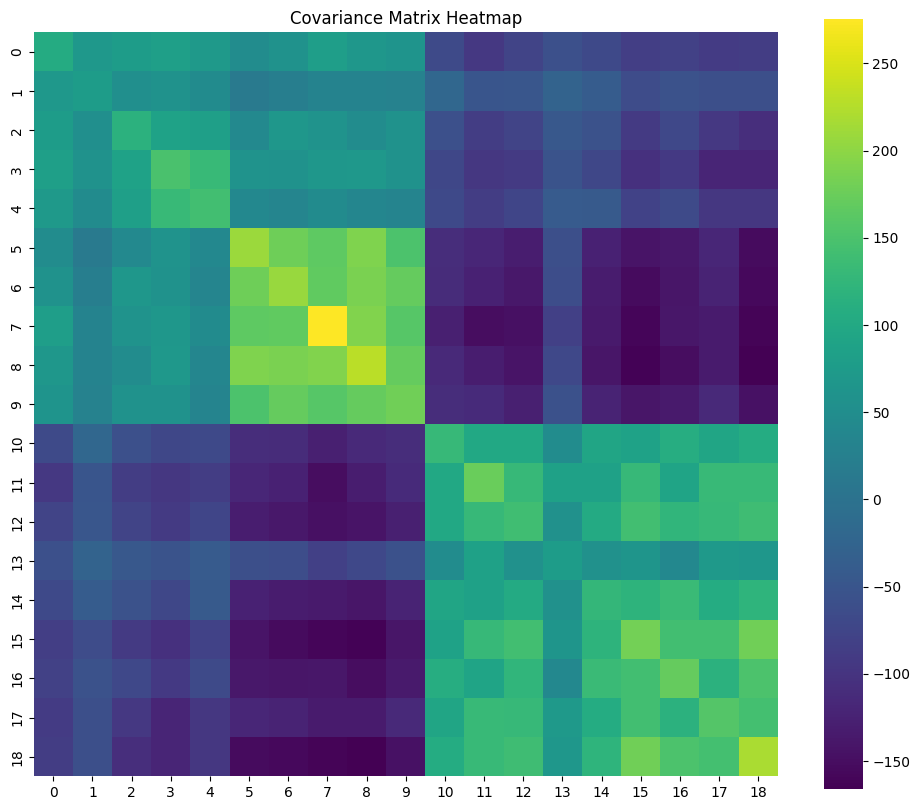

Shape of covariance matrix: (19, 19)

Maximum value: 275.2695994023364
Minimum value: -166.13698316332807
Mean value: -1.2596879525940834e-15


In [40]:
covariance_matrix = B @ B.T

plt.figure(figsize=(12, 10))
sns.heatmap(covariance_matrix, 
            cmap='viridis',
            square=True)
plt.title('Covariance Matrix Heatmap')
plt.show()

# Print some basic statistics about the covariance matrix
print("Shape of covariance matrix:", covariance_matrix.shape)
print("\nMaximum value:", np.max(covariance_matrix))
print("Minimum value:", np.min(covariance_matrix))
print("Mean value:", np.mean(covariance_matrix))

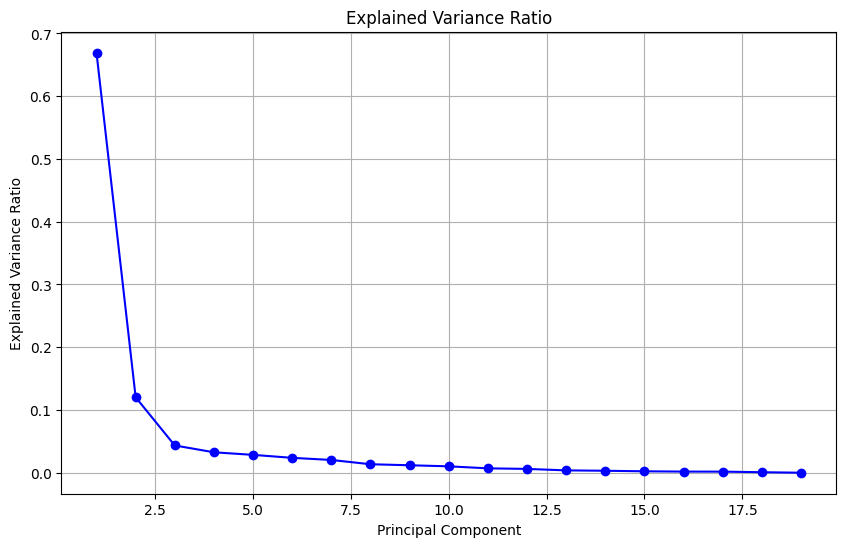

In [41]:
# Calculate the principal components (PCs)
# The columns of Vt are the right singular vectors (eigenvectors of B^T B)
PCs = Vt.T  # This gives us the principal components

# Calculate the scores (projections of the data onto the PCs)
scores = B @ PCs

# Calculate the explained variance ratio
total_var = np.sum(s**2)
explained_var_ratio = (s**2) / total_var

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, 'bo-')
plt.title('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [42]:
# Print the cumulative explained variance
cumulative_var = np.cumsum(explained_var_ratio)
print("Cumulative explained variance ratio:")
for i, var in enumerate(cumulative_var):
    print(f"PC{i+1}: {var:.4f}")

Cumulative explained variance ratio:
PC1: 0.6692
PC2: 0.7894
PC3: 0.8329
PC4: 0.8654
PC5: 0.8939
PC6: 0.9176
PC7: 0.9379
PC8: 0.9514
PC9: 0.9633
PC10: 0.9735
PC11: 0.9805
PC12: 0.9865
PC13: 0.9903
PC14: 0.9934
PC15: 0.9957
PC16: 0.9975
PC17: 0.9992
PC18: 1.0000
PC19: 1.0000


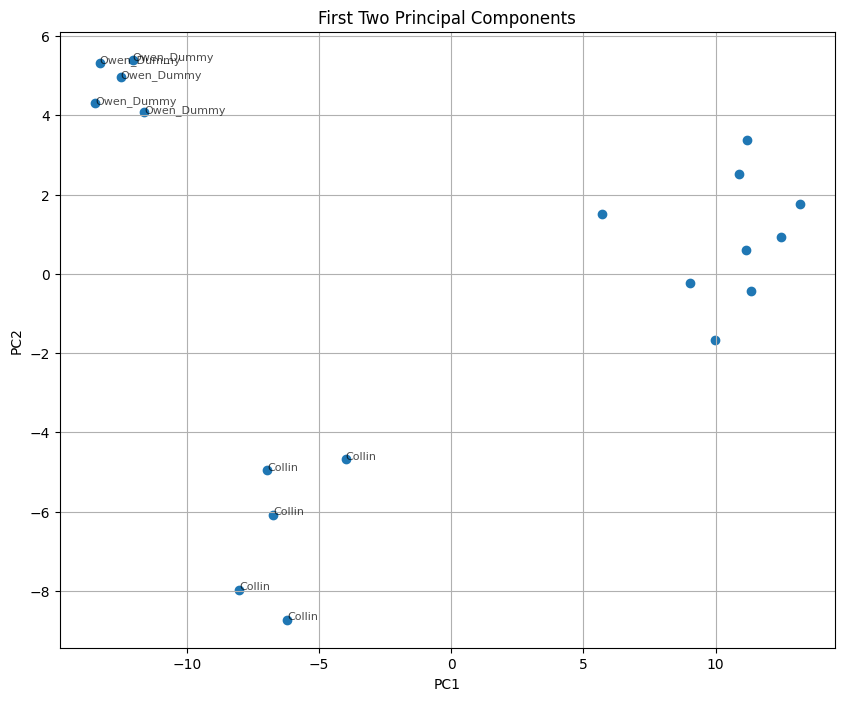

In [44]:
plt.figure(figsize=(10, 8))
plt.scatter(scores[:, 0], scores[:, 1])

# Add text labels
for i, label in enumerate(labels):
    plt.text(scores[i, 0], scores[i, 1], str(label), fontsize=8, alpha=0.7)

plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

Look at the loadings

In [138]:
loadings = pd.DataFrame(Vt.T)

# ——— Loop to pull out max index & value per column ———
for col in loadings.columns:
    max_idx = loadings[col].idxmax()   # label of the row with the max
    max_val = loadings[col].max()      # the max value itself
    min_idx = loadings[col].idxmin()   # label of the row with the max
    min_val = loadings[col].min()      # the max value itself
    print(f"Column '{col}': max = {max_val} at index '{max_idx}'")
    print(f"Column '{col}': min = {min_val} at index '{min_idx}'")
    print("\n")

Column '0': max = 0.10708033931830578 at index '63'
Column '0': min = -0.10628422419105926 at index '52'


Column '1': max = 0.14158734189471264 at index '58'
Column '1': min = -0.1384717863168669 at index '122'


Column '2': max = 0.16017975682306054 at index '89'
Column '2': min = -0.1692711505551158 at index '41'


Column '3': max = 0.18823585772568885 at index '169'
Column '3': min = -0.17377702470249617 at index '108'


Column '4': max = 0.3108716253539217 at index '92'
Column '4': min = -0.17711824788257688 at index '97'


Column '5': max = 0.17308610482259748 at index '85'
Column '5': min = -0.18586264366505106 at index '90'


Column '6': max = 0.1598476790452697 at index '84'
Column '6': min = -0.2127335455332993 at index '98'


Column '7': max = 0.19377902625175564 at index '101'
Column '7': min = -0.24630291383497419 at index '27'


Column '8': max = 0.36702858794663545 at index '96'
Column '8': min = -0.29599431338842375 at index '99'


Column '9': max = 0.3000418881350443 a